Removed no burn in
Removed no burn in


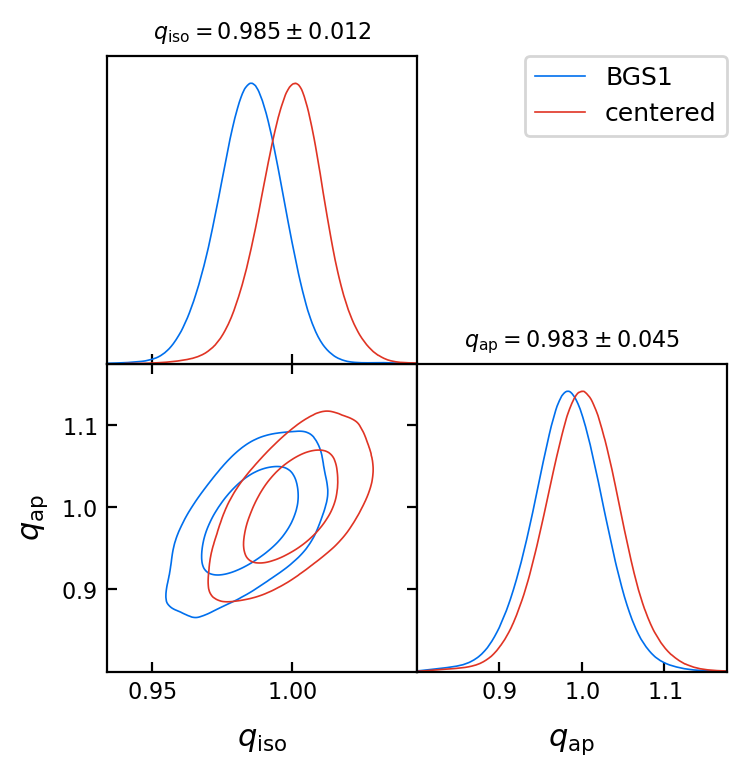

In [1]:
import sys
sys.path.insert(0, '../../../desilike')
sys.path.insert(0, '../../../desi-clustering')

from pathlib import Path
import matplotlib.pyplot as plt

from desilike.samples import MCSamples, Profiles, plotting
from cosmoprimo.fiducial import AbacusSummit

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

params_toplot = ['qiso', 'qap']

truth = {}


def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples


dirname = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/fits/bao/with_desi-clustering/')
dirname_centered = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/fits/bao/centered_alphas/')

for tracer, basename in {'BGS1': 'template-bao_BGS1-C2R-04031e03', 'LRG1': 'template-bao_LRG1-C2R-87f87260',
                         'LRG2': 'template-bao_LRG2-C2R-a9326aab', 'LRG3': 'template-bao_LRG3-C2R-ceab2a2e',
                         'ELG2': 'template-bao_ELG2-C2R-0813091f', 'QSO1': 'template-bao_QSO1-C2R-8eba6faa'}.items():
    samples, legends = [], []
    samples.append(read_samples([dirname / f'{basename}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append(tracer)
    samples.append(read_samples([dirname_centered / f'{basename}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('centered')
    mean, cov = samples[-1].mean(params=params_toplot), samples[-1].covariance(params=params_toplot)
    plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
    plt.show()
    break